
Total samples: 44000

FEATURE MEANS BY COLOR:

       red_ratio  green_ratio  blue_ratio    S_mean     S_std    V_mean  \
Color                                                                     
blue    0.000074     0.000021    0.999904  0.853857  0.010355  0.747510   
green   0.000063     0.998904    0.001031  0.843697  0.009657  0.618355   
red     0.998682     0.000006    0.001311  0.835442  0.008889  0.703346   

          V_std  
Color            
blue   0.040511  
green  0.036415  
red    0.046282  


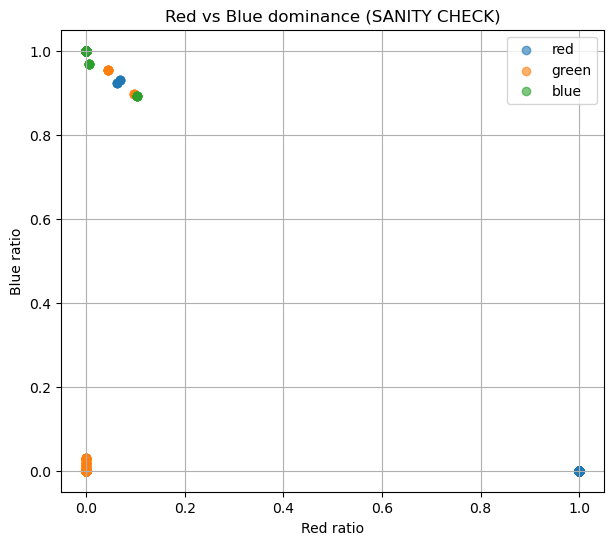


Training model...

Train accuracy: 0.9990625
Test accuracy:  0.9992045454545454

Classification report:

              precision    recall  f1-score   support

        blue       1.00      1.00      1.00      2938
       green       1.00      1.00      1.00      2924
         red       1.00      1.00      1.00      2938

    accuracy                           1.00      8800
   macro avg       1.00      1.00      1.00      8800
weighted avg       1.00      1.00      1.00      8800



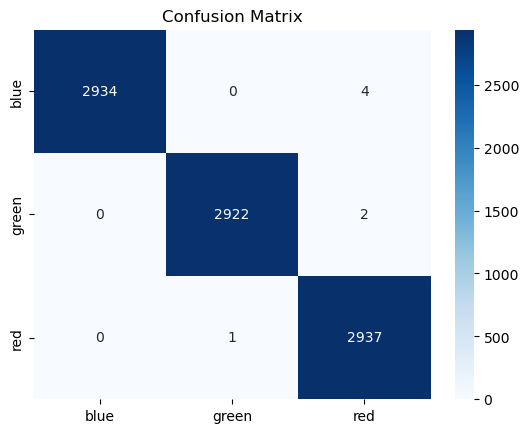


CV mean accuracy: 0.9992897727272727

✅ Model saved: hsv_mlp_model.pkl


In [10]:
"""
FINAL HSV COLOR CLASSIFIER
Red / Green / Blue
Robust, interpretable, robotics-safe
"""

from pathlib import Path
import numpy as np
import cv2
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# ============================================================
# FEATURE EXTRACTION (ROBUST & CORRECT)
# ============================================================

def extract_hsv_features(image_path):
    img = cv2.imread(str(image_path))
    if img is None:
        return None

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h = hsv[:, :, 0].astype(np.float32)   # 0..179
    s = hsv[:, :, 1].astype(np.float32)   # 0..255
    v = hsv[:, :, 2].astype(np.float32)   # 0..255

    # ----------------------------------
    # IGNORE LOW-COLOR PIXELS (CRITICAL)
    # ----------------------------------
    mask = (s > 60) & (v > 40)
    if np.count_nonzero(mask) < 50:
        return None

    h = h[mask]
    s = s[mask]
    v = v[mask]

    # ----------------------------------
    # SATURATION / VALUE STATS
    # ----------------------------------
    s_mean = np.mean(s) / 255.0
    s_std  = np.std(s)  / 255.0
    v_mean = np.mean(v) / 255.0
    v_std  = np.std(v)  / 255.0

    # ----------------------------------
    # HUE DOMINANCE (STRICT BANDS)
    # ----------------------------------
    red_mask   = (h <= 8) | (h >= 172)
    green_mask = (h >= 40) & (h <= 80)
    blue_mask  = (h >= 100) & (h <= 130)

    total = len(h)

    red_ratio   = np.sum(red_mask)   / total
    green_ratio = np.sum(green_mask) / total
    blue_ratio  = np.sum(blue_mask)  / total

    # Normalização defensiva
    ratios = np.array([red_ratio, green_ratio, blue_ratio])
    ratios = ratios / (np.sum(ratios) + 1e-6)

    return np.array([
        ratios[0], ratios[1], ratios[2],
        s_mean, s_std,
        v_mean, v_std
    ], dtype=np.float32)

# ============================================================
# DATASET LOADING
# ============================================================

def load_dataset(root_dir):
    root_dir = Path(root_dir)
    X, y = [], []

    for color in ("red", "green", "blue"):
        color_dir = root_dir / color
        if not color_dir.exists():
            continue

        for img_path in color_dir.glob("*.*"):
            feat = extract_hsv_features(img_path)
            if feat is not None:
                X.append(feat)
                y.append(color)

    return np.array(X), np.array(y)

# ============================================================
# VISUAL DEBUG (MANDATORY SANITY CHECK)
# ============================================================

def visualize_features(X, y):
    names = [
        "red_ratio", "green_ratio", "blue_ratio",
        "S_mean", "S_std", "V_mean", "V_std"
    ]

    df = pd.DataFrame(X, columns=names)
    df["Color"] = y

    print("\nFEATURE MEANS BY COLOR:\n")
    print(df.groupby("Color").mean())

    plt.figure(figsize=(7, 6))
    for color in df["Color"].unique():
        subset = df[df["Color"] == color]
        plt.scatter(
            subset["red_ratio"],
            subset["blue_ratio"],
            label=color,
            alpha=0.6
        )

    plt.xlabel("Red ratio")
    plt.ylabel("Blue ratio")
    plt.title("Red vs Blue dominance (SANITY CHECK)")
    plt.legend()
    plt.grid(True)
    plt.show()

# ============================================================
# TRAINING PIPELINE
# ============================================================

def train_model(folds_path):
    base = Path(folds_path)

    X_all, y_all = [], []

    for fold in base.glob("fold_*"):
        for split in ("train", "val"):
            split_dir = fold / split
            if split_dir.exists():
                Xp, yp = load_dataset(split_dir)
                if len(yp) > 0:
                    X_all.append(Xp)
                    y_all.append(yp)

    X = np.vstack(X_all)
    y = np.concatenate(y_all)

    print(f"\nTotal samples: {len(y)}")
    visualize_features(X, y)

    # Encode labels
    le = LabelEncoder()
    y_enc = le.fit_transform(y)

    # Split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_enc,
        test_size=0.2,
        stratify=y_enc,
        random_state=42
    )

    # Scale (safe now)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test  = scaler.transform(X_test)

    # Stable MLP (not guessing color anymore)
    clf = MLPClassifier(
    hidden_layer_sizes=(10, 6),
    activation="relu",
    solver="adam",
    alpha=0.002,
    max_iter=1200,
    early_stopping=True,
    n_iter_no_change=40,
    random_state=42
)


    print("\nTraining model...")
    clf.fit(X_train, y_train)

    print("\nTrain accuracy:", clf.score(X_train, y_train))
    print("Test accuracy: ", clf.score(X_test, y_test))

    y_pred = clf.predict(X_test)

    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred, target_names=le.classes_))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        cmap="Blues"
    )
    plt.title("Confusion Matrix")
    plt.show()

    cv = cross_val_score(clf, X_train, y_train, cv=5)
    print("\nCV mean accuracy:", cv.mean())

    joblib.dump(
        {
            "model": clf,
            "scaler": scaler,
            "label_encoder": le,
            "features": [
                "red_ratio", "green_ratio", "blue_ratio",
                "S_mean", "S_std",
                "V_mean", "V_std"
            ]
        },
        "hsv_mlp_model.pkl"
    )

    print("\n✅ Model saved: hsv_mlp_model.pkl")

# ============================================================

if __name__ == "__main__":
    train_model("cubes_classification_folds")


=== EXTRACTING MEAN HSV (CIRCULAR HUE) ===

--- fold_0 ---
  red: 2350
  green: 2350
  blue: 2350
  red: 588
  green: 588
  blue: 588

--- fold_1 ---
  red: 2350
  green: 2350
  blue: 2350
  red: 588
  green: 588
  blue: 588

--- fold_2 ---
  red: 2350
  green: 2350
  blue: 2350
  red: 588
  green: 588
  blue: 588

--- fold_3 ---
  red: 2351
  green: 2351
  blue: 2351
  red: 587
  green: 587
  blue: 587

--- fold_4 ---
  red: 2351
  green: 2351
  blue: 2351
  red: 587
  green: 587
  blue: 587

Total samples: 44070
red: 14690
green: 14690
blue: 14690

=== MEAN ± STD HSV BY COLOR ===
                H                      S                      V           
             mean        std        mean        std        mean        std
Color                                                                     
blue   119.989716   0.148718  217.673584   8.350919  190.633072  55.389584
green   61.781719   5.987852  212.416534  21.060495  156.511642  69.214066
red     76.531036  88.535538  212.99

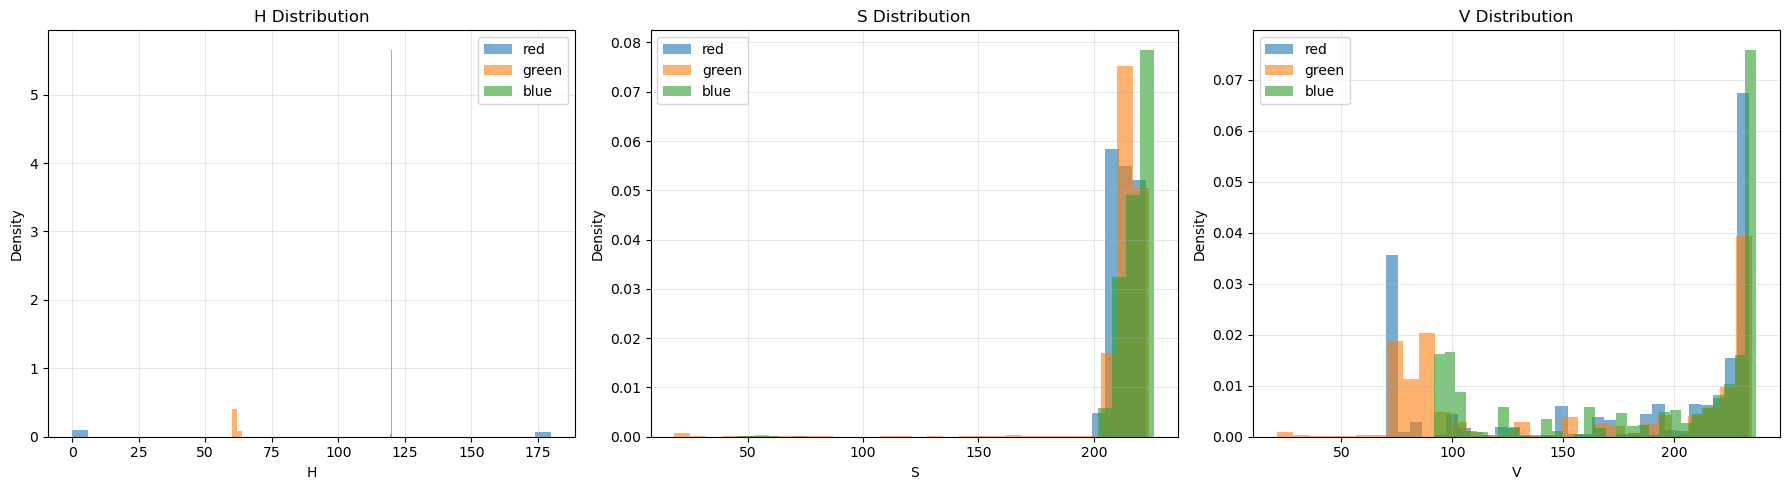

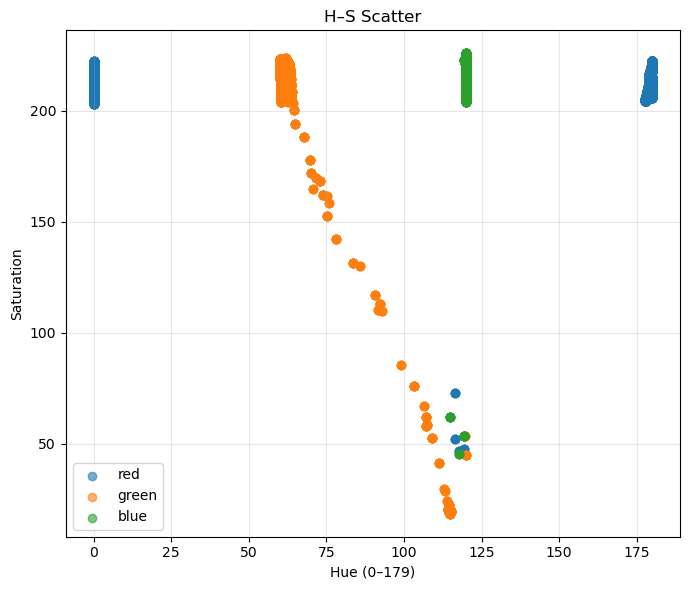

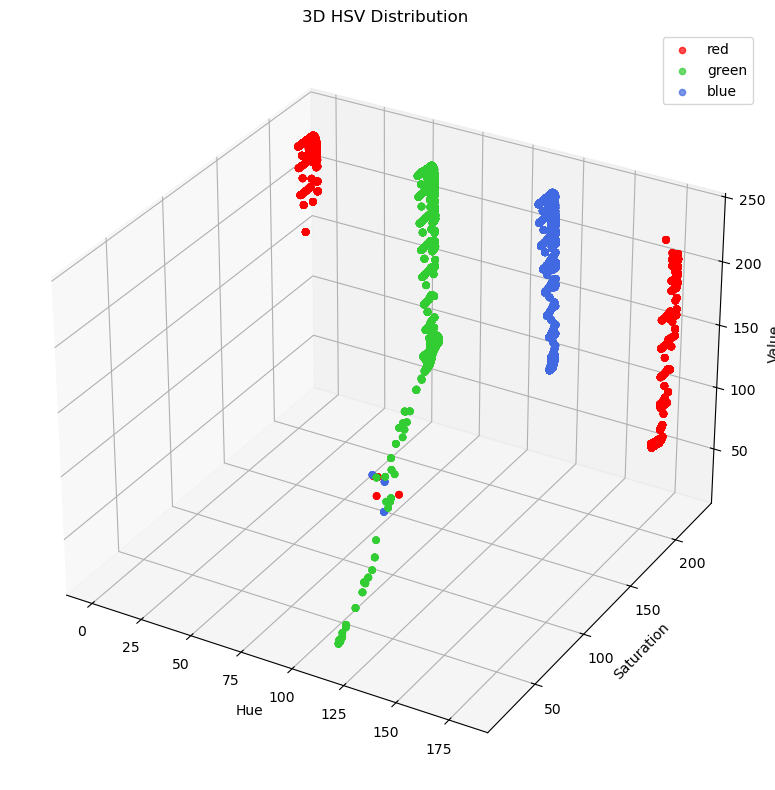

C:\Users\User\AppData\Local\Temp\ipykernel_13400\23285953.py:163: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_13400\23285953.py:163: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(
C:\Users\User\AppData\Local\Temp\ipykernel_13400\23285953.py:163: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[i].boxplot(


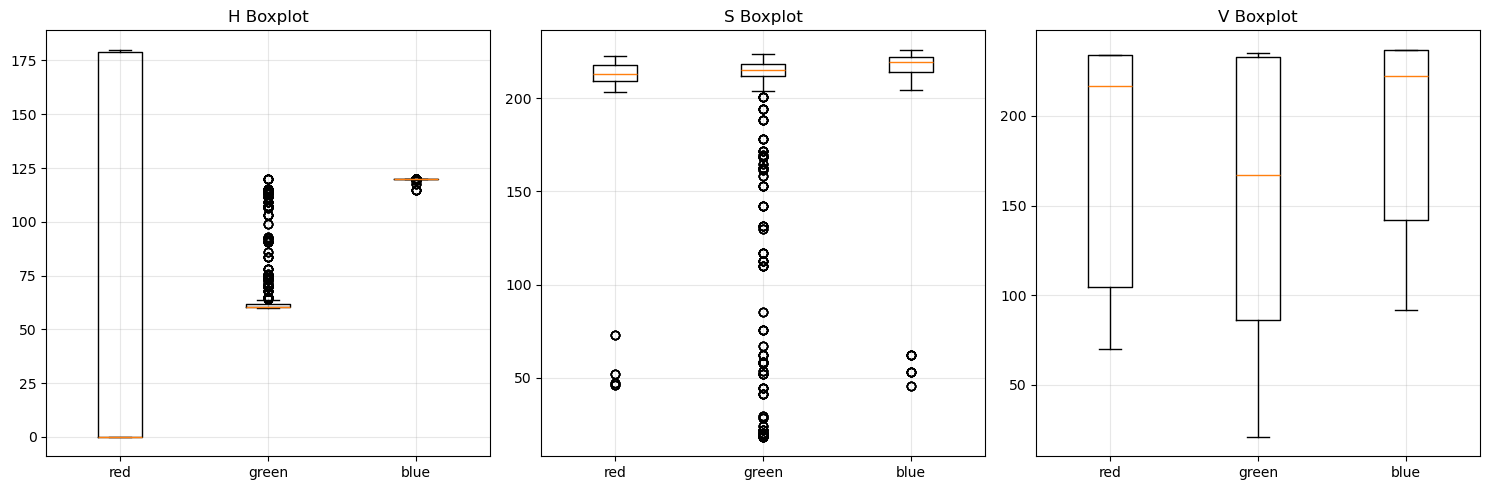

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import pandas as pd
from scipy.stats import circmean
from mpl_toolkits.mplot3d import Axes3D


# ============================================================
# HSV FEATURE EXTRACTION (CORRECT — CIRCULAR HUE)
# ============================================================

def extract_mean_hsv(image_path: str) -> np.ndarray:
    img = cv2.imread(image_path)
    if img is None:
        raise ValueError(f"Image not found: {image_path}")

    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

    h = hsv[:, :, 0].astype(np.float32)  # 0–179
    s = hsv[:, :, 1].astype(np.float32)  # 0–255
    v = hsv[:, :, 2].astype(np.float32)  # 0–255

    # --- Circular mean for Hue ---
    # OpenCV H: 0–179 → degrees = *2
    h_rad = np.deg2rad(h * 2.0)
    mean_h_rad = circmean(h_rad.flatten(), high=2*np.pi, low=0)
    mean_h_deg = np.rad2deg(mean_h_rad) % 360.0
    mean_h = mean_h_deg / 2.0  # back to 0–179

    return np.array([
        mean_h,
        s.mean(),
        v.mean()
    ], dtype=np.float32)


# ============================================================
# DATASET ANALYSIS
# ============================================================

def analyze_class_separability(dataset_path="cubes_classification_folds"):
    base_path = Path(dataset_path)
    if not base_path.exists():
        raise FileNotFoundError(base_path)

    hsv_data = []
    labels = []
    colors = ["red", "green", "blue"]

    print("=== EXTRACTING MEAN HSV (CIRCULAR HUE) ===")

    for fold in sorted(base_path.glob("fold_*")):
        print(f"\n--- {fold.name} ---")
        for split in ["train", "val"]:
            split_dir = fold / split
            if not split_dir.exists():
                continue

            for color in colors:
                color_dir = split_dir / color
                if not color_dir.exists():
                    continue

                count = 0
                for ext in ("png", "jpg", "jpeg", "bmp"):
                    for img_path in color_dir.glob(f"*.{ext}"):
                        try:
                            hsv = extract_mean_hsv(str(img_path))
                            hsv_data.append(hsv)
                            labels.append(color)
                            count += 1
                        except Exception as e:
                            print(f"Error: {img_path} → {e}")

                if count > 0:
                    print(f"  {color}: {count}")

    hsv_data = np.vstack(hsv_data)
    labels = np.array(labels)

    print(f"\nTotal samples: {len(labels)}")
    for c in colors:
        print(f"{c}: {(labels == c).sum()}")

    df = pd.DataFrame(hsv_data, columns=["H", "S", "V"])
    df["Color"] = labels

    # ========================================================
    # STATISTICS
    # ========================================================

    print("\n=== MEAN ± STD HSV BY COLOR ===")
    stats = df.groupby("Color").agg(["mean", "std"])
    print(stats)

    print("\n=== CLASS SEPARABILITY (|μ1-μ2| / pooled σ) ===")
    for feature in ["H", "S", "V"]:
        print(f"\n{feature}:")
        for i, c1 in enumerate(colors):
            for c2 in colors[i+1:]:
                x1 = df[df["Color"] == c1][feature]
                x2 = df[df["Color"] == c2][feature]
                pooled_std = np.sqrt((x1.std()**2 + x2.std()**2) / 2)
                sep = abs(x1.mean() - x2.mean()) / pooled_std
                print(f"  {c1} vs {c2}: {sep:.2f}")

    # ========================================================
    # PLOTS
    # ========================================================

    # Histograms
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, feature in enumerate(["H", "S", "V"]):
        ax = axes[i]
        for color in colors:
            data = df[df["Color"] == color][feature]
            ax.hist(data, bins=30, alpha=0.6, density=True, label=color)
        ax.set_title(f"{feature} Distribution")
        ax.set_xlabel(feature)
        ax.set_ylabel("Density")
        ax.legend()
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # H-S Scatter
    plt.figure(figsize=(7, 6))
    for color in colors:
        subset = df[df["Color"] == color]
        plt.scatter(subset["H"], subset["S"], label=color, alpha=0.6)
    plt.xlabel("Hue (0–179)")
    plt.ylabel("Saturation")
    plt.title("H–S Scatter")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    # 3D HSV Scatter
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")
    cmap = {"red": "red", "green": "limegreen", "blue": "royalblue"}
    for color in colors:
        subset = df[df["Color"] == color]
        ax.scatter(
            subset["H"], subset["S"], subset["V"],
            color=cmap[color], label=color, alpha=0.7
        )
    ax.set_xlabel("Hue")
    ax.set_ylabel("Saturation")
    ax.set_zlabel("Value")
    ax.set_title("3D HSV Distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    # Boxplots
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    for i, feature in enumerate(["H", "S", "V"]):
        axes[i].boxplot(
            [df[df["Color"] == c][feature] for c in colors],
            labels=colors
        )
        axes[i].set_title(f"{feature} Boxplot")
        axes[i].grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    return df, stats


# ============================================================
# RUN
# ============================================================

if __name__ == "__main__":
    df, stats = analyze_class_separability("cubes_classification_folds")
